In [2]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\DHANANJAY\mini project 3
['.ipynb_checkpoints', 'best_gcn_purchase_intent.pth', 'best_gru_purchase_intent.pth', 'gnn_model.ipynb', 'gru_history.pkl', 'gru_model.ipynb', 'item_encoder.pkl', 'model.ipynb', 'session_sequences.csv', 'session_sequences.pkl', 'yoochoose-buys.csv', 'yoochoose-clicks.csv', 'youchoose_preprocess.ipynb']


In [3]:
import pandas as pd
import joblib

session_sequences = pd.read_pickle("session_sequences.pkl")
item_encoder = joblib.load("item_encoder.pkl")

print(session_sequences.head())

   SessionID                             ItemSequence  Label  SequenceLength
0          1                 [1251, 1250, 1252, 4963]      0               4
1          2  [9947, 9947, 17967, 16798, 16800, 2701]      0               6
2          3                    [15777, 17206, 18918]      0               3
3          4                           [19645, 14154]      0               2
4          6                           [13686, 18072]      0               2


In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense, Dropout

In [5]:
# Vocabulary size (+1 because 0 is reserved for padding)
VOCAB_SIZE = len(item_encoder.classes_) + 1

model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=64
    ),

    GRU(64),

    Dropout(0.3),

    Dense(32, activation="relu"),

    Dropout(0.2),

    Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru (GRU)                            │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA Available: True
GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [7]:
import pandas as pd
import numpy as np
import joblib
import torch

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import TensorDataset, DataLoader

In [8]:
session_sequences = pd.read_pickle("session_sequences.pkl")
item_encoder = joblib.load("item_encoder.pkl")

print(session_sequences.head())


   SessionID                             ItemSequence  Label  SequenceLength
0          1                 [1251, 1250, 1252, 4963]      0               4
1          2  [9947, 9947, 17967, 16798, 16800, 2701]      0               6
2          3                    [15777, 17206, 18918]      0               3
3          4                           [19645, 14154]      0               2
4          6                           [13686, 18072]      0               2


In [9]:
MAX_LEN = 20

sequences = [
    torch.tensor(seq[:MAX_LEN], dtype=torch.long)
    for seq in session_sequences["ItemSequence"]
]

X = pad_sequence(
    sequences,
    batch_first=True,
    padding_value=0
)

# Ensure exactly MAX_LEN
X = X[:, :MAX_LEN]

y = torch.tensor(
    session_sequences["Label"].values,
    dtype=torch.float32
)

print(X.shape)
print(y.shape)

torch.Size([266910, 20])
torch.Size([266910])


In [10]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y.numpy()
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp.numpy()
)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)


torch.Size([186837, 20])
torch.Size([40036, 20])
torch.Size([40037, 20])


In [11]:
classes = np.array([0, 1])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train.numpy().astype(int)
)

pos_weight = torch.tensor(
    class_weights[1],
    dtype=torch.float32
)

print("Positive Weight:", pos_weight)

Positive Weight: tensor(7.5938)


In [12]:
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=512,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=512,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=512,
    shuffle=False
)

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [14]:
import torch.nn as nn

class GRUPurchasePredictor(nn.Module):
    def __init__(self, vocab_size, embedding_dim=64, hidden_dim=64):
        super(GRUPurchasePredictor, self).__init__()

        # Embedding Layer
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=0
        )

        # GRU Layer
        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True
        )

        # Dropout
        self.dropout = nn.Dropout(0.3)

        # Fully Connected Layers
        self.fc1 = nn.Linear(hidden_dim, 32)
        self.relu = nn.ReLU()

        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):

        x = self.embedding(x)

        _, hidden = self.gru(x)

        hidden = hidden.squeeze(0)

        hidden = self.dropout(hidden)

        hidden = self.fc1(hidden)

        hidden = self.relu(hidden)

        output = self.fc2(hidden)

        return output

In [15]:
VOCAB_SIZE = len(item_encoder.classes_) + 1

model = GRUPurchasePredictor(
    vocab_size=VOCAB_SIZE,
    embedding_dim=64,
    hidden_dim=64
)

model = model.to(device)

print(model)

GRUPurchasePredictor(
  (embedding): Embedding(21129, 64, padding_idx=0)
  (gru): GRU(64, 64, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)


In [16]:
criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight.to(device)
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [17]:
print(model)

print("\nDevice:", device)

print("\nPositive Weight:", pos_weight)

GRUPurchasePredictor(
  (embedding): Embedding(21129, 64, padding_idx=0)
  (gru): GRU(64, 64, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=32, out_features=1, bias=True)
)

Device: cuda

Positive Weight: tensor(7.5938)


In [18]:
import copy
from sklearn.metrics import accuracy_score

EPOCHS = 20
PATIENCE = 3

train_losses = []
val_losses = []
val_accuracies = []

best_val_loss = float("inf")
best_model = None
patience_counter = 0

In [19]:
model = GRUPurchasePredictor(
    vocab_size=VOCAB_SIZE,
    embedding_dim=64,
    hidden_dim=64
).to(device)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight.to(device)
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [20]:
import copy

EPOCHS = 20
PATIENCE = 3
MIN_DELTA = 0.001

train_losses = []
val_losses = []
val_accuracies = []

best_val_loss = float("inf")
best_model = None
patience_counter = 0

In [21]:
for epoch in range(EPOCHS):

    # -----------------------------
    # Training
    # -----------------------------
    model.train()
    running_train_loss = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch).squeeze()

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader)
    train_losses.append(train_loss)

    # -----------------------------
    # Validation
    # -----------------------------
    model.eval()

    running_val_loss = 0

    predictions = []
    actuals = []

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch).squeeze()

            loss = criterion(outputs, y_batch)

            running_val_loss += loss.item()

            probs = torch.sigmoid(outputs)

            preds = (probs >= 0.5).float()

            predictions.extend(preds.cpu().numpy())
            actuals.extend(y_batch.cpu().numpy())

    val_loss = running_val_loss / len(val_loader)
    val_losses.append(val_loss)

    val_accuracy = accuracy_score(actuals, predictions)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Accuracy: {val_accuracy:.4f}"
    )

    # -----------------------------
    # Early Stopping
    # -----------------------------
    if val_loss < best_val_loss - MIN_DELTA:

        best_val_loss = val_loss
        best_model = copy.deepcopy(model.state_dict())
        patience_counter = 0

        print("✓ Validation loss improved. Best model saved.")

    else:

        patience_counter += 1

        print(f"No improvement ({patience_counter}/{PATIENCE})")

        if patience_counter >= PATIENCE:

            print("\nEarly stopping triggered!")
            break

Epoch [1/20] Train Loss: 0.8352 Val Loss: 0.7664 Val Accuracy: 0.8656
✓ Validation loss improved. Best model saved.
Epoch [2/20] Train Loss: 0.6823 Val Loss: 0.6833 Val Accuracy: 0.8205
✓ Validation loss improved. Best model saved.
Epoch [3/20] Train Loss: 0.6000 Val Loss: 0.6637 Val Accuracy: 0.8411
✓ Validation loss improved. Best model saved.
Epoch [4/20] Train Loss: 0.5525 Val Loss: 0.7123 Val Accuracy: 0.8296
No improvement (1/3)
Epoch [5/20] Train Loss: 0.5157 Val Loss: 0.7107 Val Accuracy: 0.8301
No improvement (2/3)
Epoch [6/20] Train Loss: 0.4879 Val Loss: 0.7353 Val Accuracy: 0.8292
No improvement (3/3)

Early stopping triggered!


In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

model.eval()

predictions = []
actuals = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch).squeeze()

        probs = torch.sigmoid(outputs)

        preds = (probs >= 0.5).float()

        predictions.extend(preds.cpu().numpy())
        actuals.extend(y_batch.cpu().numpy())

print("Accuracy :", accuracy_score(actuals, predictions))
print("Precision:", precision_score(actuals, predictions))
print("Recall   :", recall_score(actuals, predictions))
print("F1 Score :", f1_score(actuals, predictions))
print("ROC AUC  :", roc_auc_score(actuals, predictions))

print("\nConfusion Matrix")
print(confusion_matrix(actuals, predictions))

print("\nClassification Report")
print(classification_report(actuals, predictions))

Accuracy : 0.8329295401753378
Precision: 0.23254586247855352
Recall   : 0.6684370257966616
F1 Score : 0.34505042592773916
ROC AUC  : 0.7564799497583079

Confusion Matrix
[[31586  5815]
 [  874  1762]]

Classification Report
              precision    recall  f1-score   support

         0.0       0.97      0.84      0.90     37401
         1.0       0.23      0.67      0.35      2636

    accuracy                           0.83     40037
   macro avg       0.60      0.76      0.62     40037
weighted avg       0.92      0.83      0.87     40037



In [23]:
torch.save(model.state_dict(), "best_gru_purchase_intent.pth")

print("Best model saved!")

Best model saved!


In [24]:
model.load_state_dict(best_model)

<All keys matched successfully>

In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

model.eval()

predictions = []
actuals = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch).squeeze()

        probs = torch.sigmoid(outputs)

        preds = (probs >= 0.5).float()

        predictions.extend(preds.cpu().numpy())
        actuals.extend(y_batch.cpu().numpy())

print("Accuracy :", accuracy_score(actuals, predictions))
print("Precision:", precision_score(actuals, predictions))
print("Recall   :", recall_score(actuals, predictions))
print("F1 Score :", f1_score(actuals, predictions))
print("ROC AUC  :", roc_auc_score(actuals, predictions))

print("\nConfusion Matrix")
print(confusion_matrix(actuals, predictions))

print("\nClassification Report")
print(classification_report(actuals, predictions))

Accuracy : 0.8466418562829383
Precision: 0.2449039021549214
Recall   : 0.6380880121396054
F1 Score : 0.35395622895622897
ROC AUC  : 0.7497143090028794

Confusion Matrix
[[32215  5186]
 [  954  1682]]

Classification Report
              precision    recall  f1-score   support

         0.0       0.97      0.86      0.91     37401
         1.0       0.24      0.64      0.35      2636

    accuracy                           0.85     40037
   macro avg       0.61      0.75      0.63     40037
weighted avg       0.92      0.85      0.88     40037



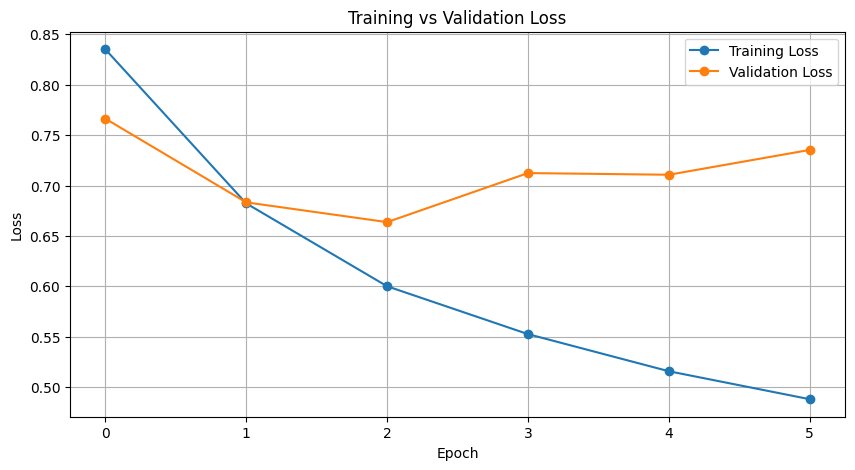

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(train_losses, marker='o', label="Training Loss")
plt.plot(val_losses, marker='o', label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)

plt.show()


In [27]:
import pickle

history = {
    "train_losses": train_losses,
    "val_losses": val_losses,
    "val_accuracies": val_accuracies
}

with open("gru_history.pkl", "wb") as f:
    pickle.dump(history, f)

In [29]:
torch.save(
    model.state_dict(),
    "best_gru_purchase_intent.pth"
)

print("Best GRU model saved successfully!")

Best GRU model saved successfully!


In [31]:
MAX_LEN = 20

def predict_session(encoded_session):

    # Keep only first MAX_LEN items
    encoded_session = encoded_session[:MAX_LEN]

    # Pad with zeros if needed
    if len(encoded_session) < MAX_LEN:
        encoded_session += [0] * (MAX_LEN - len(encoded_session))

    # Convert to tensor
    x = torch.tensor([encoded_session], dtype=torch.long).to(device)

    model.eval()

    with torch.no_grad():

        logits = model(x)

        probability = torch.sigmoid(logits).item()

    prediction = "Purchase" if probability >= 0.5 else "No Purchase"

    print(f"Purchase Probability : {probability:.4f}")
    print(f"Prediction           : {prediction}")

    return probability, prediction

In [32]:
predict_session([245, 782, 421])

Purchase Probability : 0.0422
Prediction           : No Purchase


(0.04224073886871338, 'No Purchase')

In [34]:
session = session_sequences.iloc[0]

prob, pred = predict_session(session["ItemSequence"])

print("Actual Label :", session["Label"])
print("Prediction   :", pred)
print("Probability  :", prob)

Purchase Probability : 0.1119
Prediction           : No Purchase
Actual Label : 0
Prediction   : No Purchase
Probability  : 0.11194813996553421


In [35]:
positive_session = session_sequences[session_sequences["Label"] == 1].iloc[0]

prob, pred = predict_session(positive_session["ItemSequence"])

print("Actual Label :", positive_session["Label"])
print("Prediction   :", pred)
print("Probability  :", prob)

Purchase Probability : 0.7076
Prediction           : Purchase
Actual Label : 1
Prediction   : Purchase
Probability  : 0.707595705986023
